# Notebook EDA de MovieLens

Ce notebook appelle les deux fonctions du module `src/utils.py` :
- `load_ratings_dataframe`
- `load_movies_dataframe`

Il affiche ensuite les 10 premières lignes de chaque DataFrame.

`Path.cwd()` : Récupère le dossier de travail actuel

In [1]:
# Imports Python
import importlib
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
# Chargement du module src/utils.py via importlib
utils = importlib.import_module("src.utils")

create_spark_session = utils.create_spark_session
load_ratings_dataframe = utils.load_ratings_dataframe
load_movies_dataframe = utils.load_movies_dataframe
clean_data = utils.clean_data
top_rated_movies = utils.top_rated_movies
most_popular_genres = utils.most_popular_genres
plot_results = utils.plot_results

## Mode de sélection de la source

> Modifier uniquement la variable `DATA` dans la cellule suivante.

Sources disponibles :
- `raw_small` -> `data/raw_small` (CSV)
- `raw_big` -> `data/raw_big` (CSV)
- `processed_small` -> `data/processed/small` (Parquet)
- `processed_big` -> `data/processed/big` (Parquet)

Exemple :
- `DATA = raw_small`

In [3]:
# Sélection de la source de données (modifier uniquement DATA)
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_root = project_root / "data"

raw_small = data_root / "raw_small"
raw_big = data_root / "raw_big"
processed_small = data_root / "processed" / "small"
processed_big = data_root / "processed" / "big"

# Choix de la source active
DATA = raw_small

if DATA in (raw_small, raw_big):
    dataset_format = "csv"
    path_ratings = DATA / "ratings.csv"
    path_movies = DATA / "movies.csv"
elif DATA in (processed_small, processed_big):
    dataset_format = "parquet"
    path_ratings = DATA / "ratings_clean.parquet"
    path_movies = DATA / "movies_clean.parquet"
else:
    raise ValueError("DATA doit être raw_small, raw_big, processed_small ou processed_big")

if not path_ratings.exists() or not path_movies.exists():
    raise FileNotFoundError(
        f"Fichiers introuvables pour DATA={DATA}: {path_ratings} | {path_movies}"
    )

print(f"Racine projet: {project_root}")
print(f"DATA: {DATA}")
print(f"Format: {dataset_format}")
print(f"ratings: {path_ratings}")
print(f"movies: {path_movies}")

Racine projet: /home/coule/Desktop/Documents/projets/sparkle-movie
DATA: /home/coule/Desktop/Documents/projets/sparkle-movie/data/raw_small
Format: csv
ratings: /home/coule/Desktop/Documents/projets/sparkle-movie/data/raw_small/ratings.csv
movies: /home/coule/Desktop/Documents/projets/sparkle-movie/data/raw_small/movies.csv


In [4]:
# Initialisation Spark et chargement des données selon la source choisie
spark = create_spark_session()

if dataset_format == "csv":
    # Chemins normalisés pour compatibilité multi-plateforme
    ratings_path_for_spark = path_ratings.resolve().as_posix()
    movies_path_for_spark = path_movies.resolve().as_posix()

    df_ratings = load_ratings_dataframe(spark, ratings_path_for_spark)
    df_movies = load_movies_dataframe(spark, movies_path_for_spark)
else:
    # Sources déjà préparées en Parquet
    df_ratings = spark.read.parquet(path_ratings.resolve().as_posix())
    df_movies = spark.read.parquet(path_movies.resolve().as_posix())

print(f"DataFrames chargés avec succès depuis {DATA.name} ({dataset_format}).")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 12:16:03 WARN Utils: Your hostname, PC-de-Bruno, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/20 12:16:03 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 12:16:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


DataFrames chargés avec succès depuis raw_small (csv).


In [5]:
# Aperçu de la structure et des 10 premières lignes
print("--- Schema ratings ---")
df_ratings.printSchema()
print("--- Top 10 ratings ---")
df_ratings.show(10, truncate=False)

print("--- Schema movies ---")
df_movies.printSchema()
print("--- Top 10 movies ---")
df_movies.show(10, truncate=False)

--- Schema ratings ---
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

--- Top 10 ratings ---
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
|1     |70     |3.0   |964982400|
|1     |101    |5.0   |964980868|
|1     |110    |4.0   |964982176|
|1     |151    |5.0   |964984041|
|1     |157    |5.0   |964984100|
+------+-------+------+---------+
only showing top 10 rows
--- Schema movies ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--- Top 10 movies ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                        

## Nettoyage des donnees
On applique `clean_data` pour retirer les valeurs manquantes critiques et les doublons.

In [6]:
# Nettoyage des DataFrames
df_ratings_clean, df_movies_clean = clean_data(df_ratings, df_movies)

print("Lignes ratings avant/apres:", df_ratings.count(), "/", df_ratings_clean.count())
print("Lignes movies avant/apres:", df_movies.count(), "/", df_movies_clean.count())

Lignes ratings avant/apres: 100836 / 100836
Lignes movies avant/apres: 9742 / 9742


## Tendances generales
On calcule le top des films par note moyenne (avec seuil minimal de votes) et les genres les plus populaires.

In [7]:
# Top films et genres populaires
df_top_movies = top_rated_movies(df_ratings_clean, df_movies_clean)
df_top_genres = most_popular_genres(df_ratings_clean, df_movies_clean)

print("--- Top 10 films les mieux notes (min 50 votes) ---")
df_top_movies.show(10, truncate=False)

print("--- Top 10 genres les plus populaires ---")
df_top_genres.show(10, truncate=False)

--- Top 10 films les mieux notes (min 50 votes) ---
+-------+---------------------------------------------------------------------------+-----------------+---------+
|movieId|title                                                                      |avg_rating       |n_ratings|
+-------+---------------------------------------------------------------------------+-----------------+---------+
|318    |Shawshank Redemption, The (1994)                                           |4.429022082018927|317      |
|858    |Godfather, The (1972)                                                      |4.2890625        |192      |
|2959   |Fight Club (1999)                                                          |4.272935779816514|218      |
|1276   |Cool Hand Luke (1967)                                                      |4.271929824561403|57       |
|750    |Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)|4.268041237113402|97       |
|904    |Rear Window (1954)         

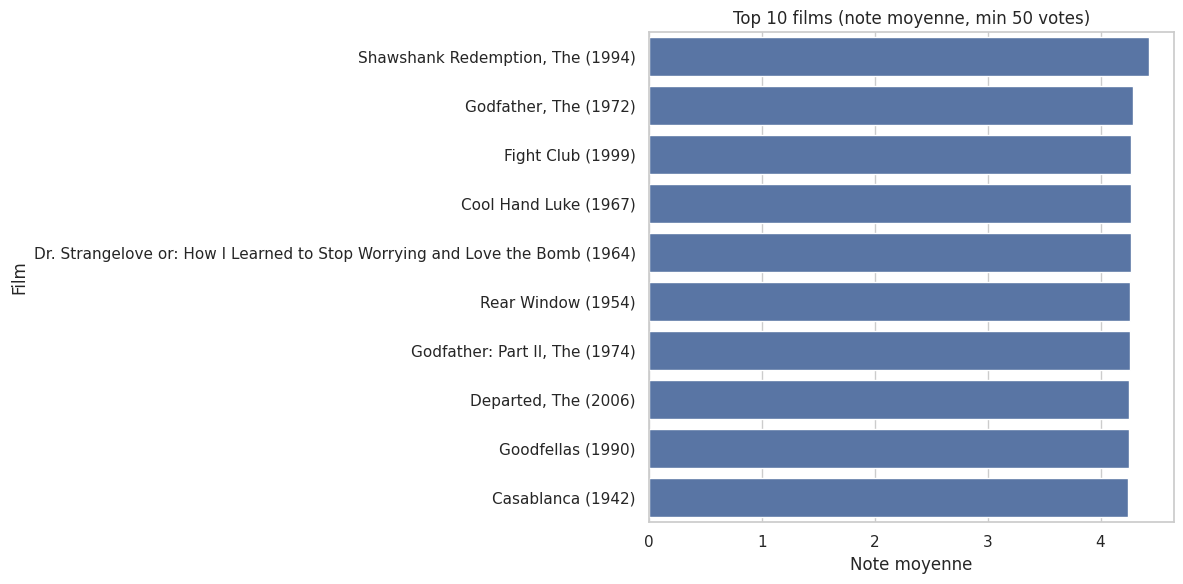

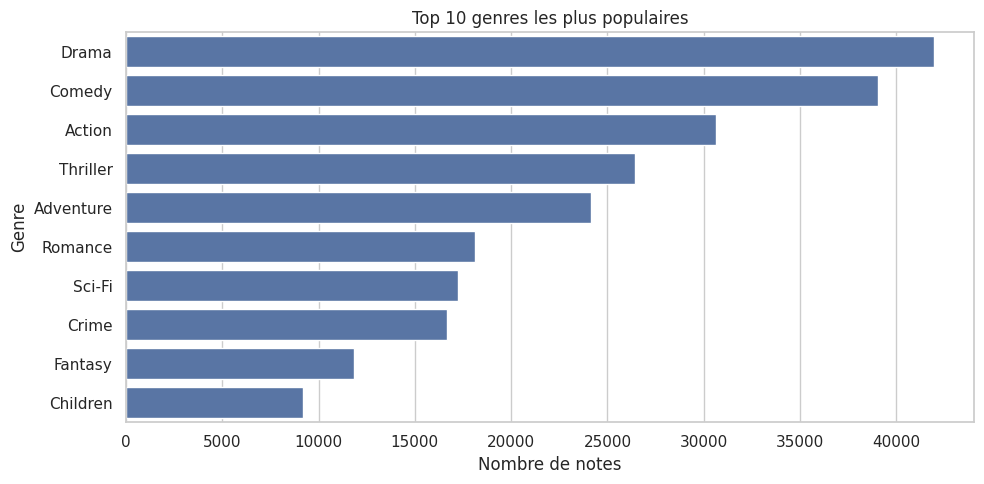

In [8]:
# Visualisations
plot_results(df_top_movies, df_top_genres)

In [9]:
# Libération propre de la session Spark
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.
